In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the base path for your specific Kaggle dataset
base_dir = '/kaggle/input/datasets/rajatkumar794/visual-based-question-answering'

# Let's list the files to verify the paths are correct
print("Checking dataset files...")
for dirname, _, filenames in os.walk(base_dir):
    for filename in filenames:
        print(os.path.join(dirname, filename))

Checking dataset files...
/kaggle/input/datasets/rajatkumar794/visual-based-question-answering/val_image_ids.txt
/kaggle/input/datasets/rajatkumar794/visual-based-question-answering/val_questions.txt
/kaggle/input/datasets/rajatkumar794/visual-based-question-answering/train_question_ids.txt
/kaggle/input/datasets/rajatkumar794/visual-based-question-answering/train_questions.txt
/kaggle/input/datasets/rajatkumar794/visual-based-question-answering/train_image_id.txt
/kaggle/input/datasets/rajatkumar794/visual-based-question-answering/val_question_ids.txt
/kaggle/input/datasets/rajatkumar794/visual-based-question-answering/val_answers.txt
/kaggle/input/datasets/rajatkumar794/visual-based-question-answering/train_answers.txt
/kaggle/input/datasets/rajatkumar794/visual-based-question-answering/v2_Questions_Val_mscoco/v2_OpenEnded_mscoco_val2014_questions.json
/kaggle/input/datasets/rajatkumar794/visual-based-question-answering/v2_Annotations_Val_mscoco/v2_mscoco_val2014_annotations.json
/ka

In [5]:
import pandas as pd
import os

base_dir = '/kaggle/input/datasets/rajatkumar794/visual-based-question-answering'

# 1. Read the files
with open(os.path.join(base_dir, 'train_image_id.txt'), 'r') as f:
    image_ids = f.read().splitlines()

with open(os.path.join(base_dir, 'train_questions.txt'), 'r') as f:
    questions = f.read().splitlines()
    
with open(os.path.join(base_dir, 'train_answers.txt'), 'r') as f:
    answers = f.read().splitlines()

# 2. Print the lengths to see where the mismatch was
print(f"Number of Image IDs: {len(image_ids)}")
print(f"Number of Questions: {len(questions)}")
print(f"Number of Answers:   {len(answers)}")

# 3. Find the shortest length and trim the lists to match
min_length = min(len(image_ids), len(questions), len(answers))
print(f"\nTrimming all data to match the shortest list ({min_length} rows)...")

# 4. Safely combine them into a DataFrame
df = pd.DataFrame({
    'image_id': image_ids[:min_length],
    'question': questions[:min_length],
    'answer': answers[:min_length]
})

print(f"\nSuccess! Total training examples loaded: {len(df)}")
display(df.head())

Number of Image IDs: 443579
Number of Questions: 443665
Number of Answers:   443547

Trimming all data to match the shortest list (443547 rows)...

Success! Total training examples loaded: 443547


,image_id,question,answer
0,458752,What is this photo taken looking through?,net
1,458752,What position is this man playing?,pitcher
2,458752,What color is the players shirt?,orange
3,458752,Is this man a professional baseball player?,yes
4,262146,What color is the snow?,white


In [6]:
# 1. Subsample the dataset for Kaggle memory limits
SAMPLE_SIZE = 30000
df_sampled = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
print(f"Sampled dataset down to {len(df_sampled)} rows.")

# 2. Find the top 1000 most common answers
NUM_ANSWERS = 1000
answer_counts = df_sampled['answer'].value_counts()
top_answers = answer_counts.head(NUM_ANSWERS).index.tolist()

print(f"\nTop 10 most common answers in our sample:")
print(answer_counts.head(10))

# 3. Filter out rows where the answer is NOT in our top 1000 list
df_filtered = df_sampled[df_sampled['answer'].isin(top_answers)].reset_index(drop=True)

print(f"\nRows remaining after keeping only top {NUM_ANSWERS} answers: {len(df_filtered)}")

Sampled dataset down to 30000 rows.

Top 10 most common answers in our sample:
answer
no       5767
yes      5686
2         829
1         789
white     618
red       386
3         385
0         335
black     331
blue      324
Name: count, dtype: int64

Rows remaining after keeping only top 1000 answers: 26587


In [7]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

print("Starting Text Preprocessing...")

# --- 1. Process the Questions ---
MAX_VOCAB_SIZE = 5000  # The top 5,000 most common words in the questions
MAX_SEQ_LENGTH = 20    # Force every question to be exactly 20 words long

# Initialize and fit the tokenizer
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(df_filtered['question'])

# Convert words to numbers and pad them with zeros so they are all the same length
X_seqs = tokenizer.texts_to_sequences(df_filtered['question'])
X_questions = pad_sequences(X_seqs, maxlen=MAX_SEQ_LENGTH, padding='post')

print(f"Questions processed! Shape: {X_questions.shape}")
print(f"Example encoded question (Row 0): {X_questions[0]}")

# --- 2. Process the Answers ---
# Convert text answers ("yes", "white") into integer IDs (0, 1, 2...)
label_encoder = LabelEncoder()
y_integers = label_encoder.fit_transform(df_filtered['answer'])

# Convert integer IDs into One-Hot Encoded arrays
NUM_CLASSES = len(label_encoder.classes_) # Should be exactly 1000
y_answers = tf.keras.utils.to_categorical(y_integers, num_classes=NUM_CLASSES)

print(f"\nAnswers processed! Shape: {y_answers.shape}")
print(f"Number of unique answer categories: {NUM_CLASSES}")

2026-05-25 13:54:27.947129: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779717268.121112      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779717268.172432      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779717268.586276      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779717268.586341      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779717268.586345      57 computation_placer.cc:177] computation placer alr

Starting Text Preprocessing...
Questions processed! Shape: (26587, 20)
Example encoded question (Row 0): [ 4 13  3  6 52  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]

Answers processed! Shape: (26587, 1000)
Number of unique answer categories: 1000


In [8]:
print("Formatting image filenames...")

# Function to pad the ID and add the COCO prefix/suffix
def format_image_filename(image_id):
    padded_id = str(image_id).zfill(12)
    return f"COCO_train2014_{padded_id}.jpg"

# Apply this function to create a new column
df_filtered['image_filename'] = df_filtered['image_id'].apply(format_image_filename)

print("Filenames formatted successfully!")
display(df_filtered[['image_id', 'question', 'image_filename']].head())

Formatting image filenames...
Filenames formatted successfully!


,image_id,question,image_filename
0,514125,What color is this cat?,COCO_train2014_000000514125.jpg
1,70339,Where is the person sitting?,COCO_train2014_000000070339.jpg
2,311121,What's the weather like in this scene?,COCO_train2014_000000311121.jpg
3,505086,What color is the bedding?,COCO_train2014_000000505086.jpg
4,202522,Where are the birds?,COCO_train2014_000000202522.jpg


In [9]:
import tensorflow as tf
import cv2
import numpy as np

# UPDATE THIS PATH to point to your newly attached COCO train2014 image folder!
COCO_IMAGE_DIR = '/kaggle/input/YOUR_COCO_DATASET_NAME_HERE/train2014/train2014'

# Double-check that the directory exists
if not os.path.exists(COCO_IMAGE_DIR):
    print(f"ERROR: Cannot find the image directory at {COCO_IMAGE_DIR}. Please check the path!")
else:
    print(f"Found image directory: {COCO_IMAGE_DIR}")

class VQADataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, questions_seq, one_hot_answers, image_dir, batch_size=32, target_size=(224, 224)):
        self.df = df
        self.questions_seq = questions_seq
        self.answers = one_hot_answers
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.target_size = target_size
        self.indexes = np.arange(len(self.df))
        
    def __len__(self):
        # Number of batches per epoch
        return int(np.floor(len(self.df) / self.batch_size))
    
    def __getitem__(self, index):
        # Generate indices of the batch
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        
        # Initialize arrays for this batch
        X_images = np.empty((self.batch_size, *self.target_size, 3))
        X_texts = np.empty((self.batch_size, self.questions_seq.shape[1]))
        y_batch = np.empty((self.batch_size, self.answers.shape[1]))
        
        for i, idx in enumerate(batch_indexes):
            # 1. Load and process the image
            filename = self.df.iloc[idx]['image_filename']
            img_path = os.path.join(self.image_dir, filename)
            
            # Read image using OpenCV
            img = cv2.imread(img_path)
            if img is None:
                # Fallback in case an image is corrupted or missing
                img = np.zeros((*self.target_size, 3), dtype=np.uint8)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
                img = cv2.resize(img, self.target_size)
            
            # Normalize pixel values to [0, 1]
            X_images[i,] = img / 255.0
            
            # 2. Add the text sequence
            X_texts[i,] = self.questions_seq[idx]
            
            # 3. Add the answer
            y_batch[i,] = self.answers[idx]
            
        return [X_images, X_texts], y_batch

print("\nData Generator class defined!")

# Let's test it by creating a generator object
train_generator = VQADataGenerator(
    df=df_filtered, 
    questions_seq=X_questions, 
    one_hot_answers=y_answers, 
    image_dir=COCO_IMAGE_DIR, 
    batch_size=32
)

print(f"Generator created! Total batches per epoch: {len(train_generator)}")

ERROR: Cannot find the image directory at /kaggle/input/YOUR_COCO_DATASET_NAME_HERE/train2014/train2014. Please check the path!

Data Generator class defined!
Generator created! Total batches per epoch: 830


In [10]:
import tensorflow as tf
import cv2
import numpy as np
import os

# We use your original base directory and append the nested train2014 folders
base_dir = '/kaggle/input/datasets/rajatkumar794/visual-based-question-answering'
COCO_IMAGE_DIR = os.path.join(base_dir, 'train2014', 'train2014')

# Double-check that the directory exists
if not os.path.exists(COCO_IMAGE_DIR):
    print(f"ERROR: Cannot find the image directory at {COCO_IMAGE_DIR}. Please check the path!")
else:
    print(f"Found image directory: {COCO_IMAGE_DIR}")

class VQADataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, questions_seq, one_hot_answers, image_dir, batch_size=32, target_size=(224, 224)):
        self.df = df
        self.questions_seq = questions_seq
        self.answers = one_hot_answers
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.target_size = target_size
        self.indexes = np.arange(len(self.df))
        
    def __len__(self):
        # Number of batches per epoch
        return int(np.floor(len(self.df) / self.batch_size))
    
    def __getitem__(self, index):
        # Generate indices of the batch
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        
        # Initialize arrays for this batch
        X_images = np.empty((self.batch_size, *self.target_size, 3))
        X_texts = np.empty((self.batch_size, self.questions_seq.shape[1]))
        y_batch = np.empty((self.batch_size, self.answers.shape[1]))
        
        for i, idx in enumerate(batch_indexes):
            # 1. Load and process the image
            filename = self.df.iloc[idx]['image_filename']
            img_path = os.path.join(self.image_dir, filename)
            
            # Read image using OpenCV
            img = cv2.imread(img_path)
            if img is None:
                # Fallback in case an image is corrupted or missing
                img = np.zeros((*self.target_size, 3), dtype=np.float32)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Convert to RGB
                img = cv2.resize(img, self.target_size)
                img = img.astype(np.float32) / 255.0 # Normalize pixel values to [0, 1]
            
            X_images[i,] = img
            
            # 2. Add the text sequence
            X_texts[i,] = self.questions_seq[idx]
            
            # 3. Add the answer
            y_batch[i,] = self.answers[idx]
            
        return [X_images, X_texts], y_batch

print("\nData Generator class defined!")

# Let's test it by creating a generator object
train_generator = VQADataGenerator(
    df=df_filtered, 
    questions_seq=X_questions, 
    one_hot_answers=y_answers, 
    image_dir=COCO_IMAGE_DIR, 
    batch_size=32
)

print(f"Generator created! Total batches per epoch: {len(train_generator)}")

Found image directory: /kaggle/input/datasets/rajatkumar794/visual-based-question-answering/train2014/train2014

Data Generator class defined!
Generator created! Total batches per epoch: 830


In [11]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Flatten, Multiply, Dropout
from tensorflow.keras.models import Model

print("Building the VQA Architecture...")

# ==========================================
# 1. THE VISION BRANCH (Eyes)
# ==========================================
# Expecting a 224x224 RGB image
image_input = Input(shape=(224, 224, 3), name='image_input')

# Load ResNet50, pre-trained on millions of images. 
# We remove the top classification layer (include_top=False) because we just want features.
resnet = ResNet50(include_top=False, weights='imagenet', input_tensor=image_input)

# Freeze ResNet50 weights to save a massive amount of training time
for layer in resnet.layers:
    layer.trainable = False

# Flatten the spatial features and reshape into a 256-dimension vector
vision_features = Flatten()(resnet.output)
vision_features = Dense(256, activation='relu', name='vision_features')(vision_features)


# ==========================================
# 2. THE LANGUAGE BRANCH (Ears)
# ==========================================
# Expecting a sequence of 20 word-integers
question_input = Input(shape=(MAX_SEQ_LENGTH,), name='question_input')

# Turn integers into dense meaning vectors
question_features = Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=256, name='word_embeddings')(question_input)

# Use an LSTM to process the sequence of words into a single 256-dimension vector
question_features = LSTM(256, name='question_lstm')(question_features)


# ==========================================
# 3. THE FUSION (The Brain)
# ==========================================
# Combine what the model sees and what it reads. 
# Multiplying the two vectors is a classic, effective VQA baseline.
merged = Multiply(name='fusion_layer')([vision_features, question_features])


# ==========================================
# 4. THE CLASSIFIER (Mouth)
# ==========================================
# Predict the answer based on the fused knowledge
x = Dense(512, activation='relu')(merged)
x = Dropout(0.5)(x) # Helps prevent the model from memorizing the training data
output = Dense(NUM_CLASSES, activation='softmax', name='answer_prediction')(x)


# ==========================================
# 5. COMPILE THE MODEL
# ==========================================
vqa_model = Model(inputs=[image_input, question_input], outputs=output)
vqa_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("\nModel built and compiled successfully!")
vqa_model.summary()

Building the VQA Architecture...


I0000 00:00:1779717532.075852      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779717532.081870      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

Model built and compiled successfully!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ image_input[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 51,727,976 (197.33 MB)

 Trainable params: 28,140,264 (107.35 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
import tensorflow as tf
import cv2
import numpy as np
import os

base_dir = '/kaggle/input/datasets/rajatkumar794/visual-based-question-answering'
COCO_IMAGE_DIR = os.path.join(base_dir, 'train2014', 'train2014')

class VQADataGenerator(tf.keras.utils.Sequence):
    # Added **kwargs to the init parameters
    def __init__(self, df, questions_seq, one_hot_answers, image_dir, batch_size=32, target_size=(224, 224), **kwargs):
        # FIX 1: Add this super() call to clear up the PyDataset warning
        super().__init__(**kwargs) 
        
        self.df = df
        self.questions_seq = questions_seq
        self.answers = one_hot_answers
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.target_size = target_size
        self.indexes = np.arange(len(self.df))
        
    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))
    
    def __getitem__(self, index):
        batch_indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        
        X_images = np.empty((self.batch_size, *self.target_size, 3))
        X_texts = np.empty((self.batch_size, self.questions_seq.shape[1]))
        y_batch = np.empty((self.batch_size, self.answers.shape[1]))
        
        for i, idx in enumerate(batch_indexes):
            filename = self.df.iloc[idx]['image_filename']
            img_path = os.path.join(self.image_dir, filename)
            
            img = cv2.imread(img_path)
            if img is None:
                img = np.zeros((*self.target_size, 3), dtype=np.float32)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, self.target_size)
                img = img.astype(np.float32) / 255.0
            
            X_images[i,] = img
            X_texts[i,] = self.questions_seq[idx]
            y_batch[i,] = self.answers[idx]
            
        # FIX 2: Replaced the list [] with a tuple () for the inputs!
        return (X_images, X_texts), y_batch

# Re-initialize the generator
train_generator = VQADataGenerator(
    df=df_filtered, 
    questions_seq=X_questions, 
    one_hot_answers=y_answers, 
    image_dir=COCO_IMAGE_DIR, 
    batch_size=32
)

print(f"Updated Generator created! Total batches per epoch: {len(train_generator)}")

Updated Generator created! Total batches per epoch: 830


In [16]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

print("Starting the training process...")

# 1. Set up Callbacks
# Save the model weights if the training accuracy improves
checkpoint = ModelCheckpoint(
    filepath='vqa_model_weights.keras', 
    monitor='loss', # We monitor loss since we aren't using a validation set in this basic setup
    save_best_only=True, 
    verbose=1
)

# Stop training early if the model stops learning for 3 epochs in a row
early_stop = EarlyStopping(
    monitor='loss', 
    patience=3, 
    verbose=1
)

# 2. Train the Model!
# We will do 5 epochs for now. You can increase this later for a better model.
EPOCHS = 3

history = vqa_model.fit(
    train_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint, early_stop]
)

print("\nTraining Complete!")

Starting the training process...
Epoch 1/3


I0000 00:00:1779717677.664964     186 cuda_dnn.cc:529] Loaded cuDNN version 91002


830/830 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.2477 - loss: 3.7437
Epoch 1: loss improved from inf to 3.36781, saving model to vqa_model_weights.keras
830/830 ━━━━━━━━━━━━━━━━━━━━ 331s 387ms/step - accuracy: 0.2477 - loss: 3.7433
Epoch 2/3
830/830 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.2708 - loss: 3.0302
Epoch 2: loss improved from 3.36781 to 2.99091, saving model to vqa_model_weights.keras
830/830 ━━━━━━━━━━━━━━━━━━━━ 190s 229ms/step - accuracy: 0.2708 - loss: 3.0302
Epoch 3/3
830/830 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.2794 - loss: 2.8790
Epoch 3: loss improved from 2.99091 to 2.88701, saving model to vqa_model_weights.keras
830/830 ━━━━━━━━━━━━━━━━━━━━ 189s 228ms/step - accuracy: 0.2794 - loss: 2.8790

Training Complete!


Setting up the testing function...


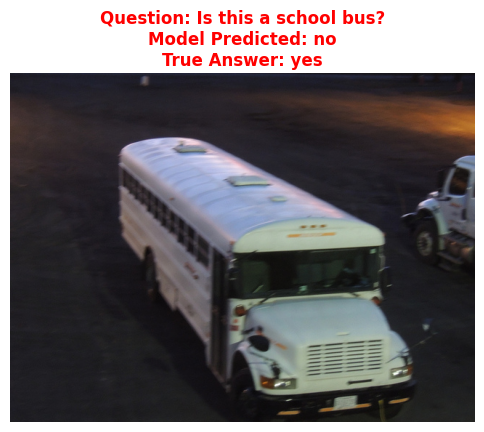

In [17]:
import matplotlib.pyplot as plt
import random

print("Setting up the testing function...")

def test_vqa_model(index):
    # 1. Grab a specific row from our data
    row = df_filtered.iloc[index]
    image_filename = row['image_filename']
    true_question = row['question']
    true_answer = row['answer']
    
    # 2. Load and format the image
    img_path = os.path.join(COCO_IMAGE_DIR, image_filename)
    img = cv2.imread(img_path)
    
    if img is None:
        print("Could not load image. Try another index.")
        return
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Keep for plotting
    
    # Resize and normalize for the model
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = img_resized.astype(np.float32) / 255.0
    
    # Add a "batch" dimension because the model expects (batch_size, 224, 224, 3)
    img_array = np.expand_dims(img_array, axis=0) 
    
    # 3. Format the text question
    seq = tokenizer.texts_to_sequences([true_question])
    padded_seq = pad_sequences(seq, maxlen=MAX_SEQ_LENGTH, padding='post')
    
    # 4. Ask the model!
    prediction = vqa_model.predict([img_array, padded_seq], verbose=0)
    
    # Find the index of the highest probability
    predicted_index = np.argmax(prediction)
    
    # Convert that index back into the English word
    predicted_word = label_encoder.inverse_transform([predicted_index])[0]
    
    # 5. Show the results visually
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    
    # Create a nice title
    title_text = f"Question: {true_question}\n"
    title_text += f"Model Predicted: {predicted_word}\n"
    title_text += f"True Answer: {true_answer}"
    
    # If it got it right, make it green. If wrong, red.
    color = 'green' if predicted_word == true_answer else 'red'
    plt.title(title_text, color=color, fontsize=12, fontweight='bold')
    plt.show()

# Run the test on a random image from our dataset!
random_idx = random.randint(0, len(df_filtered) - 1)
test_vqa_model(random_idx)

In [18]:
# Install gradio (Kaggle usually has it, but this ensures we have the latest version)
!pip install gradio -q

import gradio as gr
from transformers import BlipProcessor, BlipForQuestionAnswering
from PIL import Image

print("Downloading and loading the BLIP model (takes about 1 minute)...")
processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model = BlipForQuestionAnswering.from_pretrained("Salesforce/blip-vqa-base").to("cuda")
print("Model loaded successfully! Launching UI...")

# This is the function the submit button will run
def answer_question(image, question):
    # Basic error handling
    if image is None:
        return "⚠️ Please upload an image first."
    if not question or question.strip() == "":
        return "⚠️ Please type a question."
    
    # Process the image and text
    inputs = processor(image, question, return_tensors="pt").to("cuda")
    
    # Generate the answer
    out = model.generate(**inputs)
    answer = processor.decode(out[0], skip_special_tokens=True)
    
    return answer

# Build the Gradio Interface
demo = gr.Interface(
    fn=answer_question,
    inputs=[
        gr.Image(type="pil", label="1. Upload any Image"),
        gr.Textbox(label="2. Ask a Question", placeholder="e.g., Is this a school bus?")
    ],
    outputs=gr.Textbox(label="BLIP's Answer", text_align="center"),
    title="Zero-Shot VQA with BLIP",
    description="Test the pre-trained Salesforce BLIP model! Upload an image, ask a question, and click Submit.",
    allow_flagging="never", # Cleans up the UI by removing unnecessary buttons
    theme=gr.themes.Soft()  # Gives it a nice modern look
)

# Launch the app inside the notebook!
# share=True also generates a temporary public web link you can share with your professor!
demo.launch(share=True, inline=True)

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully! Launching UI...


/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://ab8c28225ae4b307a5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
